In [15]:
# importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
# loading the dataset
data = pd.read_csv('train_dataset1.csv')


In [5]:
# printing the first few rows of the dataset
print(data.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [6]:
# checking for missing values
print("\nMissing values in each column:\n", data.isnull().sum())



Missing values in each column:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [7]:
# handling numerical missing values by filling with mean
numerical_cols = data.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    data[col].fillna(data[col].mean(), inplace=True)
# handling categorical missing values by filling with mode
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)
# encoding categorical variables using one-hot encoding
data = pd.get_dummies(data, drop_first=True)


C:\Users\Keerthana\AppData\Local\Temp\ipykernel_5420\910255089.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)
C:\Users\Keerthana\AppData\Local\Temp\ipykernel_5420\910255089.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [8]:
# checling for missing values after handling
print("\nMissing values after handling:\n", data.isnull().sum())



Missing values after handling:
 ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
                          ..
Education_Not Graduate     0
Self_Employed_Yes          0
Property_Area_Semiurban    0
Property_Area_Urban        0
Loan_Status_Y              0
Length: 628, dtype: int64


In [9]:
# detecting the target variable and features
X = data.drop('Loan_Status_Y', axis=1)
y = data['Loan_Status_Y']

In [10]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [11]:
# training the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# making predictions
y_pred = model.predict(X_test)
# printing the  predicted values
print("\nPredicted values:\n", y_pred)




Predicted values:
 [ True  True  True  True  True  True  True  True  True  True False  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True False
  True  True  True  True  True  True  True  True  True  True  True False
 False False  True  True False  True  True  True  True  True False  True
 False  True False  True  True  True  True  True  True  True False  True
  True  True False  True  True False False  True  True  True  True  True
  True  True  True False  True  True  True False False  True  True  True
  True  True  True  True  True  True  True  True  True False  True False
  True  True  True False  True  True  True  True  True  True  True  True
  True  True  True]


c:\Users\Keerthana\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
y_pred = model.predict(X_test)

y_pred = y_pred.astype(int)

print(y_pred)

[1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1
 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 1]


In [13]:
# evaluating the model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("\nAccuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)



Accuracy: 0.7886178861788617

Confusion Matrix:
 [[18 25]
 [ 1 79]]

Classification Report:
               precision    recall  f1-score   support

       False       0.95      0.42      0.58        43
        True       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



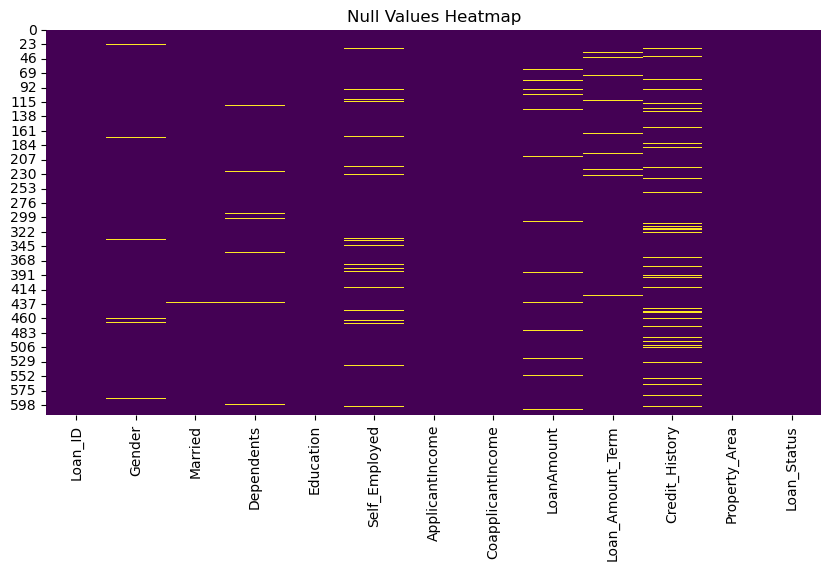

In [18]:
import seaborn as sns
# Null values visualization
plt.figure(figsize=(10,5))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')

plt.title("Null Values Heatmap")
plt.show()

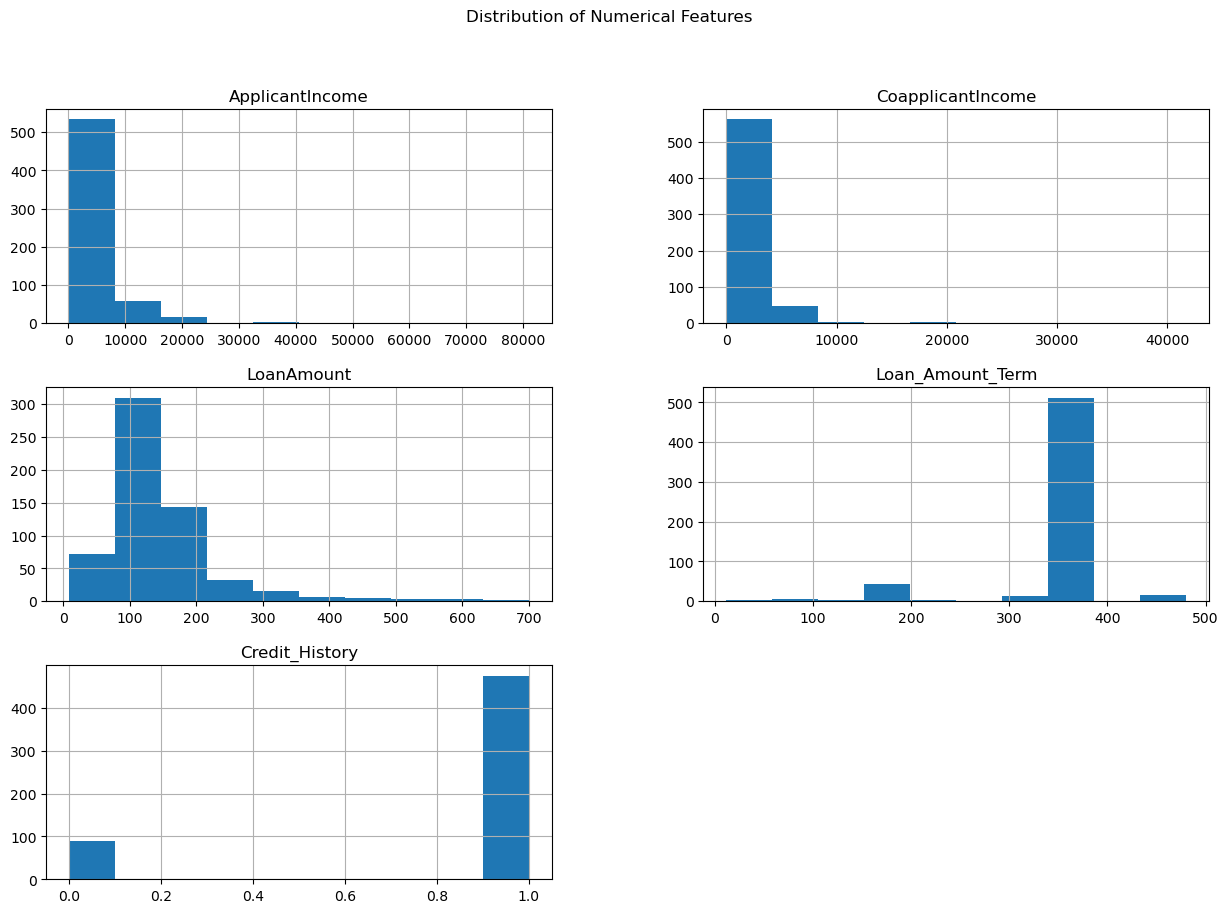

In [19]:
# Histogram for numerical columns
data.hist(figsize=(15,10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

In [22]:
# 4. Handle null values

# Numerical columns
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].median())

data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(
    data['Loan_Amount_Term'].median()
)

data['Credit_History'] = data['Credit_History'].fillna(
    data['Credit_History'].mode()[0]
)

# Categorical columns
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])

data['Married'] = data['Married'].fillna(data['Married'].mode()[0])

data['Dependents'] = data['Dependents'].fillna(
    data['Dependents'].mode()[0]
)

data['Self_Employed'] = data['Self_Employed'].fillna(
    data['Self_Employed'].mode()[0]
)

print("Null Values After Handling:")
print(data.isnull().sum())


# Convert categorical columns to numeric
data['Gender'] = data['Gender'].replace({
    'Male':1,
    'Female':0
})

data['Married'] = data['Married'].replace({
    'Yes':1,
    'No':0
})

data['Education'] = data['Education'].replace({
    'Graduate':1,
    'Not Graduate':0
})

data['Self_Employed'] = data['Self_Employed'].replace({
    'Yes':1,
    'No':0
})

data['Property_Area'] = data['Property_Area'].replace({
    'Rural':0,
    'Semiurban':1,
    'Urban':2
})

data['Loan_Status'] = data['Loan_Status'].replace({
    'Y':1,
    'N':0
})

# Dependents
data['Dependents'] = data['Dependents'].replace('3+', 3)
data['Dependents'] = data['Dependents'].astype(int)

# Remove Loan_ID
data.drop('Loan_ID', axis=1, inplace=True)

print(data.head())

Null Values After Handling:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          1              0             5849   
1       1        1           1          1              0             4583   
2       1        1           0          1              1             3000   
3       1        1           0          0              0             2583   
4       1        0           0          1              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0       

C:\Users\Keerthana\AppData\Local\Temp\ipykernel_5420\965556531.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Gender'] = data['Gender'].replace({
C:\Users\Keerthana\AppData\Local\Temp\ipykernel_5420\965556531.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Married'] = data['Married'].replace({
C:\Users\Keerthana\AppData\Local\Temp\ipykernel_5420\965556531.py:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call 

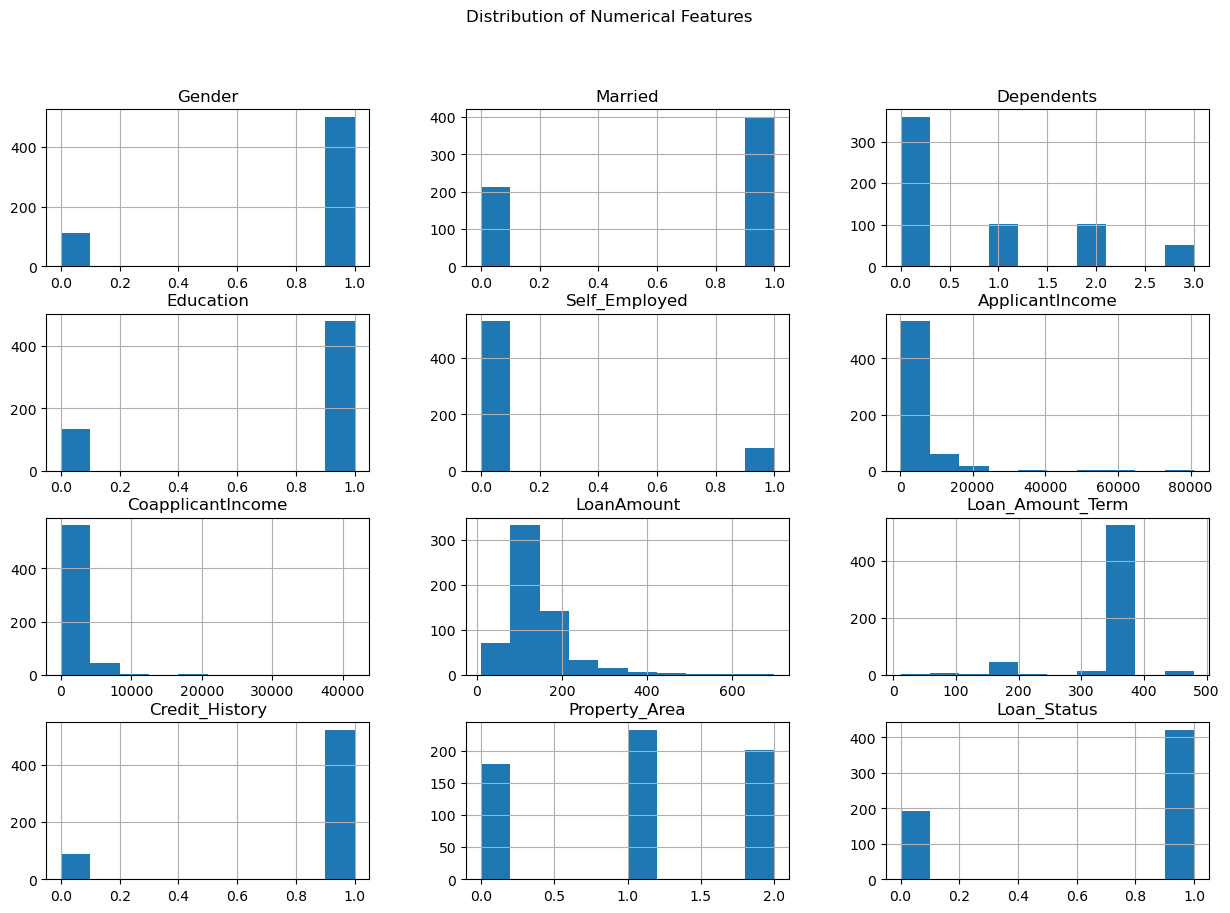

In [24]:
# Histogram for numerical columns
data.hist(figsize=(15,10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

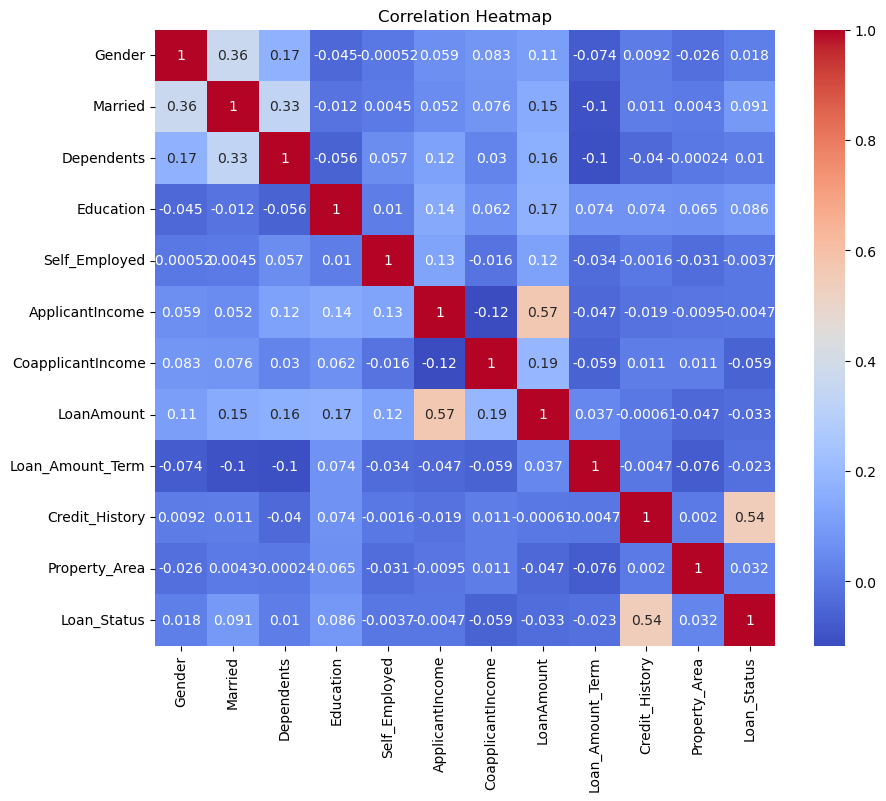

In [26]:
# Correlation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

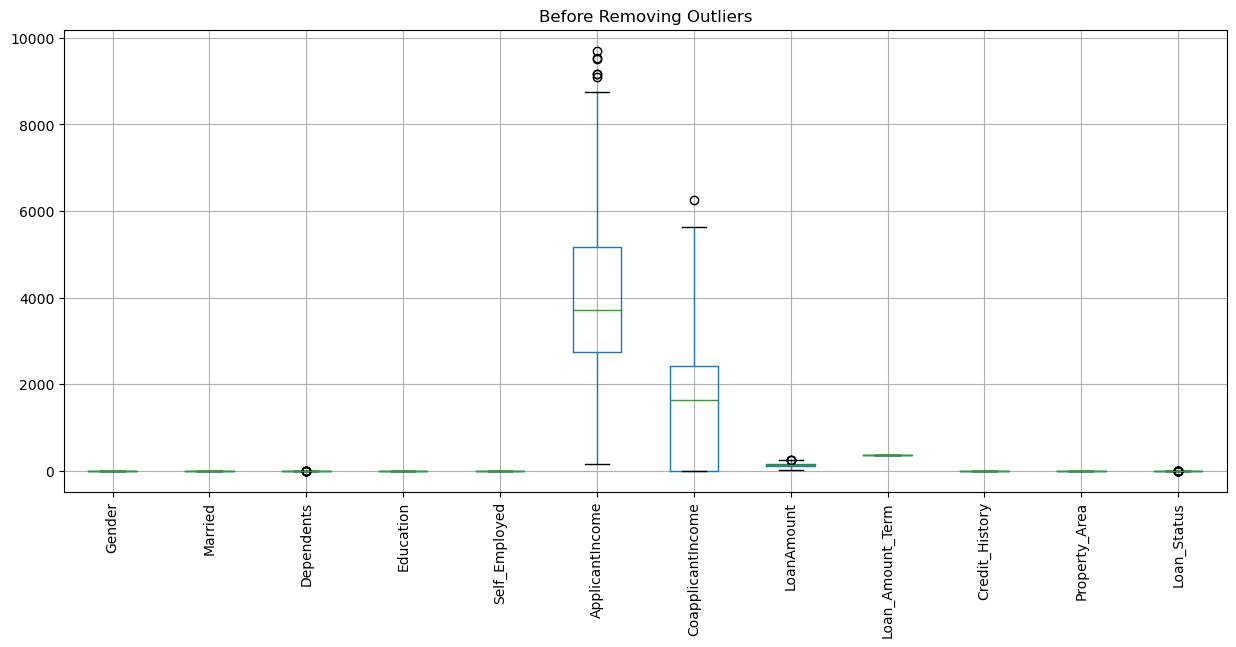

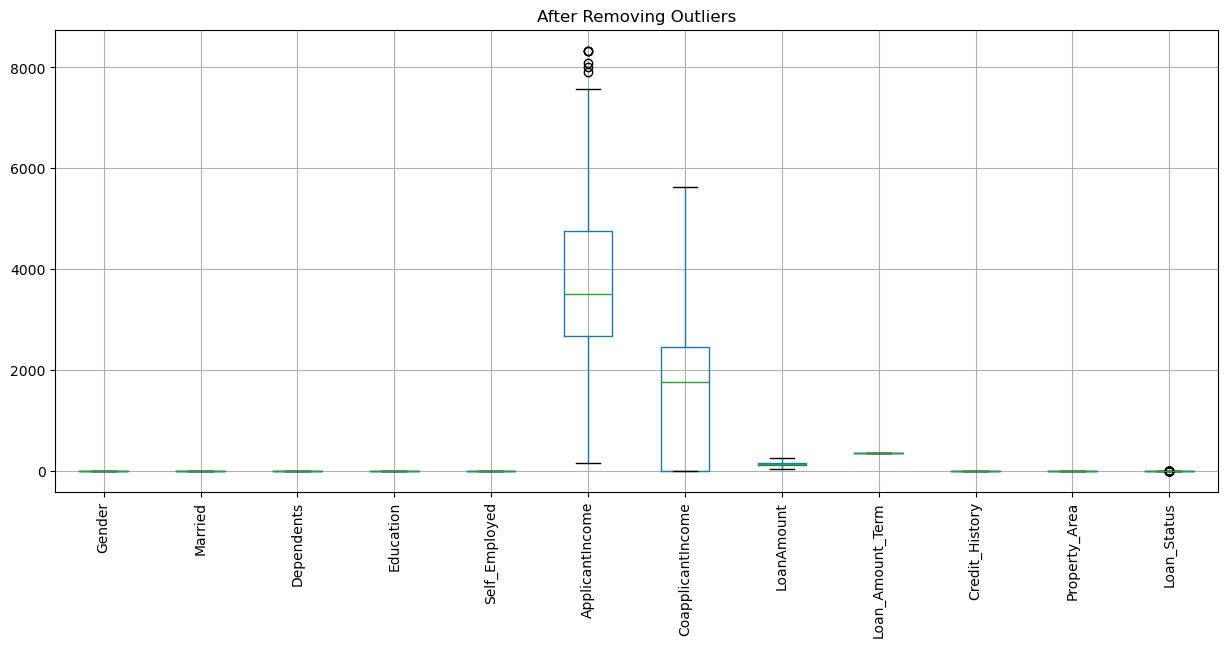

Original Shape: (217, 12)
After Removing Outliers: (194, 12)

Reason:
We removed outliers because extreme values can reduce
Logistic Regression accuracy.
If dataset size becomes too small,
we avoid removing too many rows.

Feature Scaling Completed


In [29]:
# 5. Find Outliers and Visualize
#import standard scaler for feature scaling
from sklearn.preprocessing import StandardScaler

numeric_cols = data.select_dtypes(include=np.number).columns

# Before removing outliers
plt.figure(figsize=(15,6))
data[numeric_cols].boxplot()
plt.title("Before Removing Outliers")
plt.xticks(rotation=90)
plt.show()

# IQR Method
data_outlier_removed = data.copy()

for col in numeric_cols:
    if col != 'Loan_Status':  # don't remove target outliers
        Q1 = data_outlier_removed[col].quantile(0.25)
        Q3 = data_outlier_removed[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        data_outlier_removed = data_outlier_removed[
            (data_outlier_removed[col] >= lower) &
            (data_outlier_removed[col] <= upper)
        ]

# After removing outliers
plt.figure(figsize=(15,6))
data_outlier_removed.boxplot()
plt.title("After Removing Outliers")
plt.xticks(rotation=90)
plt.show()

print("Original Shape:", data.shape)
print("After Removing Outliers:", data_outlier_removed.shape)

print("""
Reason:
We removed outliers because extreme values can reduce
Logistic Regression accuracy.
If dataset size becomes too small,
we avoid removing too many rows.
""")

# Use cleaned dataset
data = data_outlier_removed

# 7. Feature Scaling
scaler = StandardScaler()

feature_cols = data.drop("Loan_Status", axis=1).columns

data[feature_cols] = scaler.fit_transform(data[feature_cols])

print("Feature Scaling Completed")

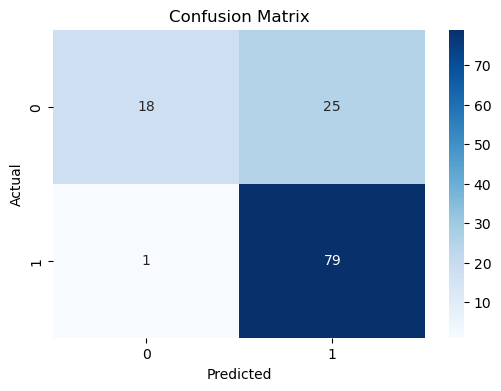

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

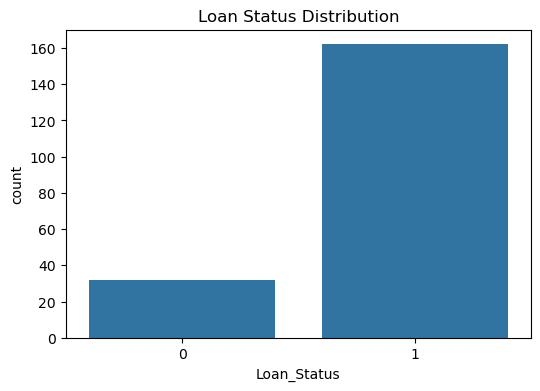

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(x='Loan_Status', data=data)

plt.title("Loan Status Distribution")
plt.show()

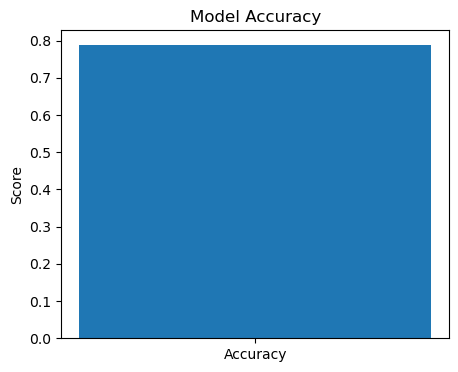

In [32]:
accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(5,4))

plt.bar(['Accuracy'], [accuracy])

plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()